# Hand Trajectory Prediction with an LSTM

**Context.** The MediaPipe hand-teleop pipeline maps webcam hand landmarks to a target
end-effector position `[x, y, z]` for MoveIt Servo pose tracking. The raw mapped position
is jittery (camera noise, landmark noise, hand-size depth estimation), so the node smooths
it with an exponential moving average (EMA, `pose_smoothing = 0.3`). The EMA tradeoff:
**more smoothing = more lag** — the robot reacts after the hand has already moved.

**Idea.** Train an LSTM to predict the hand's **displacement** `HORIZON` frames *ahead*
from a window of the last `SEQ_LEN` raw positions (the window is expressed relative to its own
last frame). Predicting displacement instead of absolute position makes the model
**translation-invariant** — motion dynamics look the same anywhere in the workspace — so it
generalizes to regions never visited during training. Trained with MSE on noisy targets, the
network learns the conditional mean of the motion: it **anticipates motion instead of lagging
behind it like the EMA** (and on jittery data the conditional mean also acts as a learned
smoother), and with `HORIZON = 3` (~100 ms at ~31 Hz) the prediction lead compensates
the camera → MediaPipe → servo pipeline latency.

**Data collection** (robot does **not** need to be running):
```bash
# terminal with the ROS workspace sourced (system python, where mediapipe lives)
ros2 run mediapipe_dual_arm_control hand_pose_publisher_node.py
```
Press **`r`** in the OpenCV window to start/stop recording, then move your hand through the whole
workspace for 5–10 minutes: slow sweeps, fast moves, holds, corners, depth (near/far). CSVs land in
`mediapipe_dual_arm_control/dataset/`. Each row:

| column | meaning |
|---|---|
| `t` | monotonic timestamp [s] |
| `seg` | segment id — increments when hand tracking was lost (never window across a gap) |
| `rx, ry, rz` | **raw** mapped robot-frame position [m], *before* smoothing → model input & target |
| `fx, fy, fz` | the node's **EMA** output [m] → lag baseline for comparison |

**Kernel:** run this notebook with the `ntnu_env` interpreter
(`~/University/NTNU/ntnu_env` — torch 2.7, pandas, matplotlib).

In [1]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

DATA_DIR = Path("../dataset")            # where the teleop node saves CSVs
MODELS_DIR = Path("../models")              # exported model goes into the ROS package

SEQ_LEN = 15      # past frames fed to the LSTM (~0.3-0.5 s of history)
HORIZON = 3       # predict this many frames ahead (~100 ms at 31 Hz: pipeline-latency lead)
HIDDEN_SIZE = 32
NUM_LAYERS = 1
BATCH_SIZE = 256
EPOCHS = 60
LR = 1e-3
TRAIN_FRAC, VAL_FRAC = 0.70, 0.15   # rest = test
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} on {device}")

torch 2.7.0+cu128 on cuda


## 1. Load the recordings

Every CSV is split into **segments**: an unbroken run of tracked frames. A new segment starts
whenever the recorded `seg` id changes (hand tracking was lost) or the timestamp jumps more than
`MAX_DT`. LSTM windows are built strictly *inside* one segment, so no training sample ever spans
a tracking gap.

In [2]:
files = sorted(DATA_DIR.glob("hand_traj_*.csv"))
assert files, (
    f"No recordings found in {DATA_DIR}.\n"
    "Run the teleop node (robot not needed) and press 'r' to record:\n"
    "  ros2 run mediapipe_dual_arm_control hand_pose_publisher_node.py"
)

MAX_DT = 0.10   # [s] a longer gap than this also breaks a segment
MIN_LEN = SEQ_LEN + HORIZON + 1

segments = []
for f in files:
    df = pd.read_csv(f)
    dt = df["t"].diff().fillna(0.0)
    run = ((df["seg"].diff().fillna(0) != 0) | (dt > MAX_DT)).cumsum()
    for _, g in df.groupby(run):
        if len(g) >= MIN_LEN:
            segments.append(g.reset_index(drop=True))

assert segments, "All segments too short — record longer continuous motion."
n_total = sum(len(s) for s in segments)
dts = np.concatenate([np.diff(s["t"].to_numpy()) for s in segments if len(s) > 1])
dt_med = float(np.median(dts))

print(f"{len(files)} file(s) -> {len(segments)} usable segment(s), {n_total} samples "
      f"(~{n_total * dt_med:.0f} s of tracked motion)")
print(f"median frame interval {dt_med * 1000:.1f} ms (~{1 / dt_med:.0f} Hz) "
      f"-> HORIZON={HORIZON} predicts {HORIZON * dt_med * 1000:.0f} ms ahead")

1 file(s) -> 1 usable segment(s), 6931 samples (~225 s of tracked motion)
median frame interval 32.5 ms (~31 Hz) -> HORIZON=3 predicts 98 ms ahead


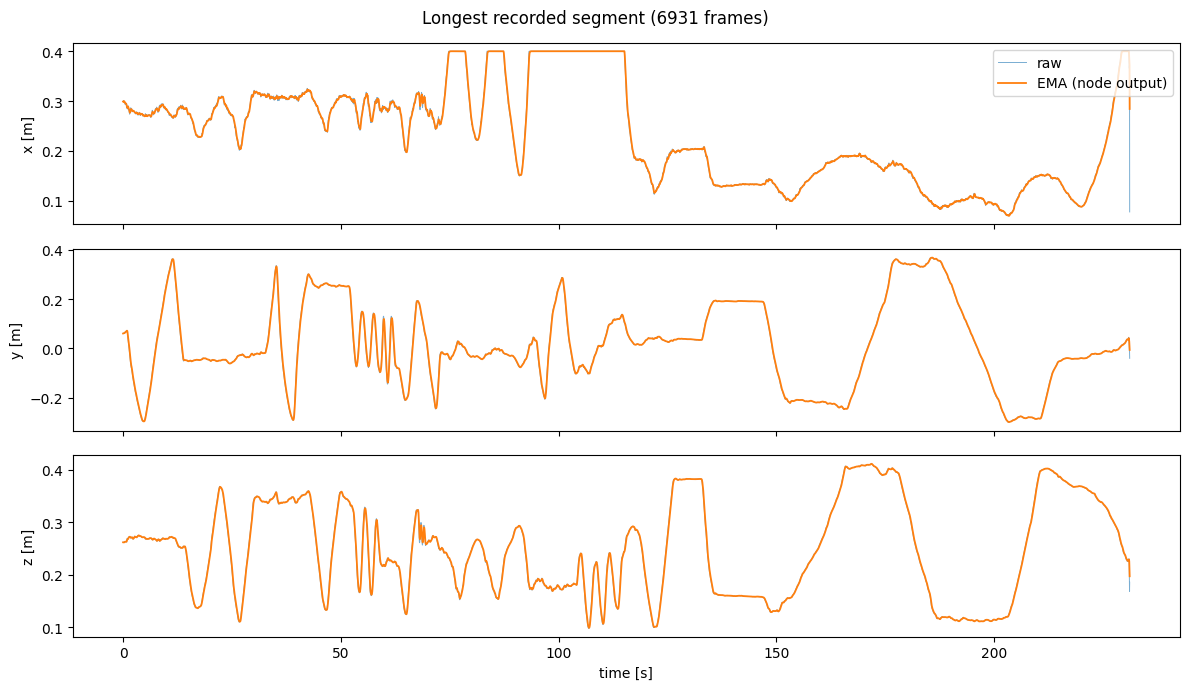

In [3]:
# What the data looks like: raw mapped position (noisy) vs the node's EMA (smooth but lagging)
seg = max(segments, key=len)
t = seg["t"].to_numpy() - seg["t"].iloc[0]

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for k, (raw_c, ema_c) in enumerate(zip(["rx", "ry", "rz"], ["fx", "fy", "fz"])):
    axes[k].plot(t, seg[raw_c], lw=0.7, alpha=0.6, label="raw")
    axes[k].plot(t, seg[ema_c], lw=1.3, label="EMA (node output)")
    axes[k].set_ylabel(f"{raw_c[1]} [m]")
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("time [s]")
fig.suptitle(f"Longest recorded segment ({len(seg)} frames)")
plt.tight_layout()
plt.show()

## 2. Windows, split, normalization

Each training sample is a sliding window: the last `SEQ_LEN` raw positions, **expressed relative
to the window's last frame**, mapped to the **displacement** from that last frame to the raw
position `HORIZON` frames later. Absolute predictions are reconstructed afterwards as
`last_frame + predicted_displacement`.

**Why displacement, not absolute position?** A first version of this notebook predicted absolute
coordinates and failed badly on real data (test MAE 10.6 mm vs 0.84 mm for the trivial persistence
baseline). The cause: with a chronological split, the test set can occupy workspace regions the
training set never visited, and an absolute-coordinate regressor cannot extrapolate there.
Displacements are translation-invariant — a left-sweep produces the same input/target pair on
either side of the workspace — so the residual model generalizes across regions. As a bonus,
predicting *zero* reproduces the persistence baseline exactly, so the model starts from a sane
default and only has to learn motion dynamics on top of it.

**Split is chronological, not random.** Consecutive frames are nearly identical; shuffling windows
before splitting would put near-duplicates of test samples into the training set (leakage) and
inflate the test score. Instead each segment is cut 70/15/15 in time order, and windows are built
per piece so none crosses a split boundary.

Inputs and targets are z-normalized with the **training** statistics of the relative windows —
the same constants are exported with the model for deployment.


In [4]:
def split_segment(s):
    n = len(s)
    i1, i2 = int(n * TRAIN_FRAC), int(n * (TRAIN_FRAC + VAL_FRAC))
    return s.iloc[:i1], s.iloc[i1:i2], s.iloc[i2:]

def make_windows(pieces):
    """X: (N, SEQ_LEN, 3) raw window RELATIVE to its last frame.
    Y: (N, 3) displacement from the last frame to the frame HORIZON ahead.
    L: (N, 3) the last raw frame (to reconstruct absolute predictions).
    E: (N, 3) the node's EMA output at the LAST input frame (the lag baseline:
    what the current pipeline would command at prediction time)."""
    X, Y, L, E = [], [], [], []
    for p in pieces:
        raw = p[["rx", "ry", "rz"]].to_numpy(np.float32)
        ema = p[["fx", "fy", "fz"]].to_numpy(np.float32)
        for i in range(len(raw) - SEQ_LEN - HORIZON + 1):
            w = raw[i:i + SEQ_LEN]
            last = w[-1]
            X.append(w - last)
            Y.append(raw[i + SEQ_LEN + HORIZON - 1] - last)
            L.append(last)
            E.append(ema[i + SEQ_LEN - 1])
    assert X, "No windows — record more data (a few minutes of motion)."
    return np.stack(X), np.stack(Y), np.stack(L), np.stack(E)

train_p, val_p, test_p = (list(p) for p in zip(*[split_segment(s) for s in segments]))
X_train, y_train, _, _ = make_windows(train_p)
X_val, y_val, _, _ = make_windows(val_p)
X_test, y_test, last_test, ema_test = make_windows(test_p)

mu = X_train.reshape(-1, 3).mean(axis=0)
sd = X_train.reshape(-1, 3).std(axis=0) + 1e-8
norm = lambda a: ((a - mu) / sd).astype(np.float32)
denorm = lambda a: a * sd + mu

print(f"train {X_train.shape}   val {X_val.shape}   test {X_test.shape}")
print(f"norm mean {np.round(mu * 1000, 3)} mm  std {np.round(sd * 1000, 3)} mm")


train (4834, 15, 3)   val (1023, 15, 3)   test (1023, 15, 3)
norm mean [ 0.177  0.411 -0.039] mm  std [ 9.404 26.468 13.344] mm


In [5]:
train_dl = DataLoader(
    TensorDataset(torch.from_numpy(norm(X_train)), torch.from_numpy(norm(y_train))),
    batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(
    TensorDataset(torch.from_numpy(norm(X_val)), torch.from_numpy(norm(y_val))),
    batch_size=BATCH_SIZE)

## 3. Model

A deliberately small network — it must run every frame inside the 50 Hz teleop loop on CPU:
one LSTM layer (hidden 32) reading the window, and a linear head mapping the final hidden state
to the predicted `[x, y, z]`. ~5k parameters.

In [6]:
class LSTMPredictor(nn.Module):
    def __init__(self, n_features=3, hidden=HIDDEN_SIZE, layers=NUM_LAYERS):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, layers, batch_first=True)
        self.fc = nn.Linear(hidden, n_features)

    def forward(self, x):              # x: (batch, SEQ_LEN, 3)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1])     # (batch, 3)

model = LSTMPredictor().to(device)
try:
    from torchinfo import summary
    print(summary(model, input_size=(1, SEQ_LEN, 3), device=device))
except ImportError:
    print(model)

Layer (type:depth-idx)                   Output Shape              Param #
LSTMPredictor                            [1, 3]                    --
├─LSTM: 1-1                              [1, 15, 32]               4,736
├─Linear: 1-2                            [1, 3]                    99
Total params: 4,835
Trainable params: 4,835
Non-trainable params: 0
Total mult-adds (M): 0.07
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.02
Estimated Total Size (MB): 0.02


In [7]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {"train": [], "val": []}
best_val, best_state = float("inf"), None

for epoch in range(1, EPOCHS + 1):
    model.train()
    tl = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        tl += loss.item() * len(xb)
    tl /= len(train_dl.dataset)

    model.eval()
    vl = 0.0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            vl += criterion(model(xb), yb).item() * len(xb)
    vl /= len(val_dl.dataset)

    history["train"].append(tl)
    history["val"].append(vl)
    if vl < best_val:
        best_val = vl
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if epoch % 5 == 0 or epoch == 1:
        print(f"epoch {epoch:3d}/{EPOCHS}   train {tl:.5f}   val {vl:.5f}"
              + ("   *" if vl == best_val else ""))

print(f"best val loss: {best_val:.5f}")

epoch   1/60   train 0.15794   val 0.02504   *
epoch   5/60   train 0.05912   val 0.01621   *


epoch  10/60   train 0.04686   val 0.01431   *


epoch  15/60   train 0.04260   val 0.01467
epoch  20/60   train 0.04026   val 0.01441


epoch  25/60   train 0.03788   val 0.01469
epoch  30/60   train 0.03626   val 0.01350   *


epoch  35/60   train 0.03517   val 0.01404
epoch  40/60   train 0.03415   val 0.01340   *


epoch  45/60   train 0.03285   val 0.01411
epoch  50/60   train 0.03255   val 0.01364


epoch  55/60   train 0.03082   val 0.01299   *
epoch  60/60   train 0.03046   val 0.01324
best val loss: 0.01299


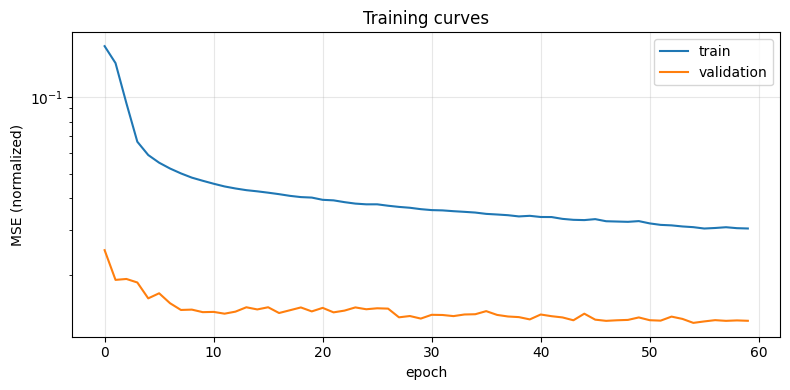

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(history["train"], label="train")
plt.plot(history["val"], label="validation")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MSE (normalized)")
plt.title("Training curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Evaluation on the held-out test split

All methods are compared in **absolute** coordinates against the raw hand position `HORIZON`
frames ahead (the LSTM's displacement output is added back onto the last input frame):

* **LSTM (ours)** — `last_frame + predicted displacement`.
* **Persistence** — predict zero displacement, i.e. copy the last raw frame ("the hand won't
  move"). The standard sanity baseline for forecasting; a useful model must beat it.
* **EMA (current node)** — what the existing pipeline commands at that moment. Its error is
  dominated by lag during motion, and it grows with the prediction horizon.


In [9]:
model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    delta = denorm(model(torch.from_numpy(norm(X_test)).to(device)).cpu().numpy())
pred = last_test + delta          # absolute LSTM prediction
y_abs = last_test + y_test        # absolute target
persist = last_test               # zero-displacement baseline

def report(name, p):
    err = p - y_abs
    mae = np.abs(err).mean() * 1000
    rmse = np.sqrt((err ** 2).mean()) * 1000
    ax_mae = np.abs(err).mean(axis=0) * 1000
    print(f"{name:<26} MAE {mae:6.2f} mm   RMSE {rmse:6.2f} mm   "
          f"per-axis MAE [x y z] = {np.round(ax_mae, 2)} mm")
    return mae

mae_lstm = report("LSTM (ours)", pred)
report("Persistence (copy last)", persist)
report("EMA (current node)", ema_test)


LSTM (ours)                MAE   1.18 mm   RMSE   5.69 mm   per-axis MAE [x y z] = [1.67 1.18 0.71] mm
Persistence (copy last)    MAE   1.99 mm   RMSE   6.25 mm   per-axis MAE [x y z] = [2.11 2.26 1.6 ] mm
EMA (current node)         MAE   3.20 mm   RMSE   7.51 mm   per-axis MAE [x y z] = [3.18 3.74 2.67] mm


np.float32(3.1958973)

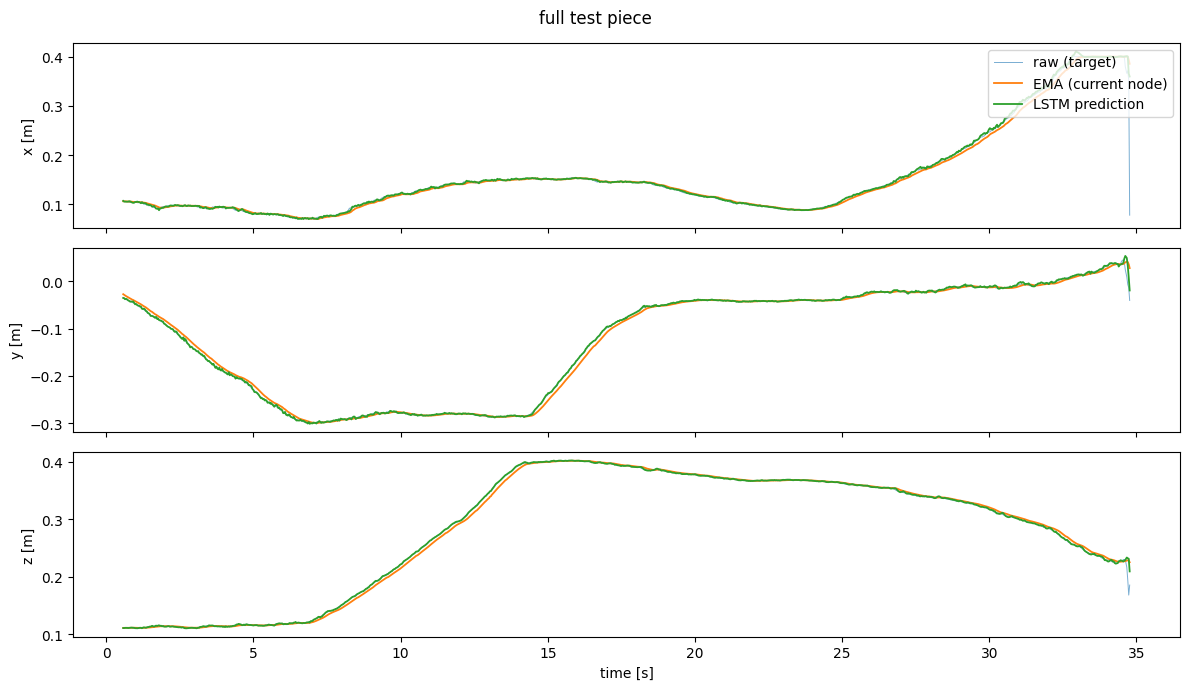

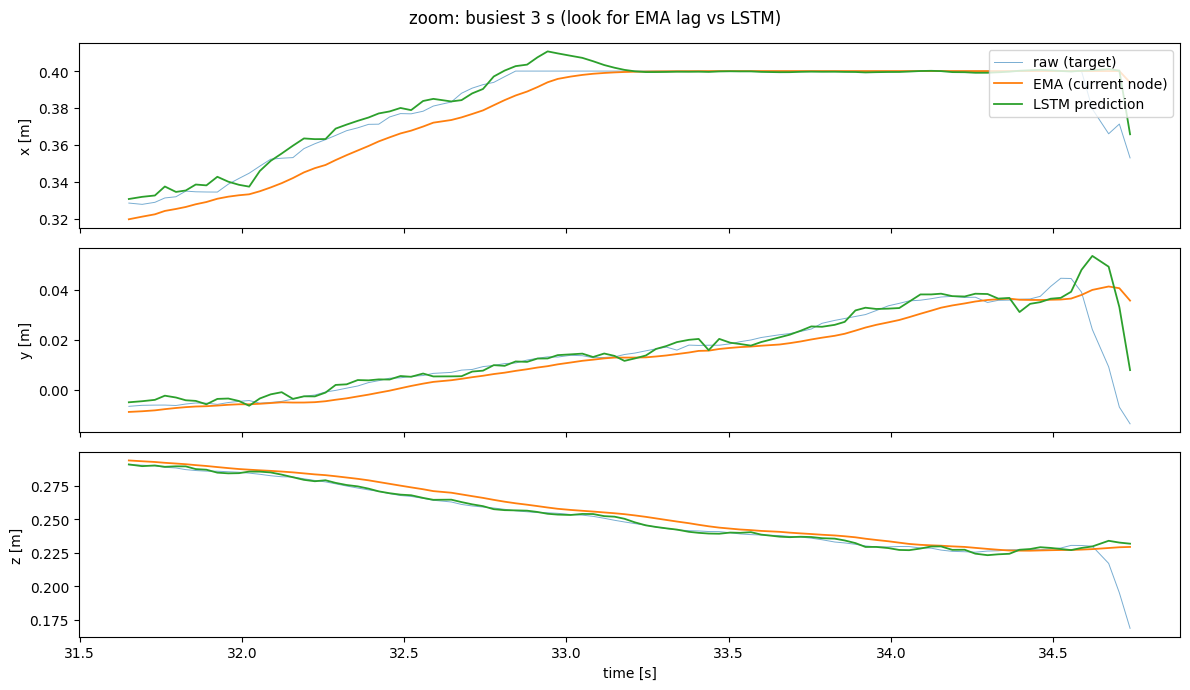

Output smoothness (mean |frame-to-frame step|, lower = smoother):
  raw  : 0.843 mm/frame
  EMA  : 0.569 mm/frame
  LSTM : 1.013 mm/frame


In [10]:
# Qualitative check on the longest test piece: full view + zoom on the busiest 3 s.
longest = max(test_p, key=len)
Xp, yp, lp, ep = make_windows([longest])
with torch.no_grad():
    pp = lp + denorm(model(torch.from_numpy(norm(Xp)).to(device)).cpu().numpy())
ya = lp + yp                      # absolute raw target
tt = longest["t"].to_numpy()
tt = (tt - tt[0])[SEQ_LEN + HORIZON - 1:]

# busiest 3-second window = where the raw target moves the most
win = max(2, min(int(3.0 / dt_med), len(tt) - 1))
speed = np.abs(np.diff(ya, axis=0)).sum(axis=1)
c = int(np.convolve(speed, np.ones(win), "same").argmax())
s0, s1 = max(0, c - win // 2), min(len(tt), c + win // 2)

for (lo, hi), title in [((0, len(tt)), "full test piece"),
                        ((s0, s1), "zoom: busiest 3 s (look for EMA lag vs LSTM)")]:
    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
    for k, name in enumerate("xyz"):
        axes[k].plot(tt[lo:hi], ya[lo:hi, k], lw=0.7, alpha=0.6, label="raw (target)")
        axes[k].plot(tt[lo:hi], ep[lo:hi, k], lw=1.3, label="EMA (current node)")
        axes[k].plot(tt[lo:hi], pp[lo:hi, k], lw=1.3, label="LSTM prediction")
        axes[k].set_ylabel(f"{name} [m]")
    axes[0].legend(loc="upper right")
    axes[-1].set_xlabel("time [s]")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

print("Output smoothness (mean |frame-to-frame step|, lower = smoother):")
for name, sig in [("raw", ya), ("EMA", ep), ("LSTM", pp)]:
    print(f"  {name:5s}: {np.abs(np.diff(sig, axis=0)).mean() * 1000:.3f} mm/frame")

## 5. Export for the ROS node

Three files into the package's `models/` directory:

* `lstm_hand_traj.pth` — plain state dict (retraining / inspection)
* `lstm_hand_traj.torchscript.pt` — TorchScript module the ROS node loads **without** needing
  this class definition
* `lstm_hand_traj.json` — normalization constants + window config the node must replicate

In [11]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_cpu = LSTMPredictor()
model_cpu.load_state_dict(best_state)
model_cpu.eval()

torch.save(best_state, MODELS_DIR / "lstm_hand_traj.pth")
torch.jit.script(model_cpu).save(MODELS_DIR / "lstm_hand_traj.torchscript.pt")
(MODELS_DIR / "lstm_hand_traj.json").write_text(json.dumps({
    "output": "displacement_from_last_input_frame",
    "lead_ms": round(HORIZON * dt_med * 1000, 1),
    "seq_len": SEQ_LEN,
    "horizon": HORIZON,
    "hidden": HIDDEN_SIZE,
    "layers": NUM_LAYERS,
    "input_mean": mu.tolist(),
    "input_std": sd.tolist(),
    "median_dt_s": dt_med,
    "test_mae_mm": round(float(mae_lstm), 3),
    "trained": time.strftime("%Y-%m-%d %H:%M"),
}, indent=2))

# sanity check: the TorchScript module matches the eager model
scripted = torch.jit.load(MODELS_DIR / "lstm_hand_traj.torchscript.pt")
x0 = torch.from_numpy(norm(X_test[:8]))
assert torch.allclose(scripted(x0), model_cpu(x0), atol=1e-5)

# CPU inference latency — must fit comfortably inside the 50 Hz (20 ms) teleop loop
x1 = torch.from_numpy(norm(X_test[:1]))
for _ in range(20):
    scripted(x1)                       # warm-up
t0 = time.perf_counter()
for _ in range(200):
    scripted(x1)
print(f"inference: {(time.perf_counter() - t0) / 200 * 1000:.2f} ms/frame (CPU)")
print("saved:", sorted(p.name for p in MODELS_DIR.glob("lstm_hand_traj.*")))

inference: 0.19 ms/frame (CPU)
saved: ['lstm_hand_traj.json', 'lstm_hand_traj.pth', 'lstm_hand_traj.torchscript.pt']


## 6. Results summary & next step

For the report (fill in from the cells above):

* Dataset: ___ samples (~___ min) recorded at ~___ Hz, chronological 70/15/15 split
* Test MAE at ~100 ms lead: LSTM ___ mm vs persistence ___ mm vs EMA (current pipeline) ___ mm
* Smoothness (mean |Δ| per frame): raw ___ mm, EMA ___ mm, LSTM ___ mm
* Design story worth telling: predicting **absolute** position failed (10.6 mm MAE — the model
  cannot extrapolate to unseen workspace regions under a leakage-safe chronological split);
  reformulating the task as **displacement** prediction made the model translation-invariant and
  it then beat both baselines.
* Interpretation: the LSTM predicts ~100 ms ahead, compensating pipeline latency — it beats
  persistence by extrapolating velocity, and beats the EMA because the EMA lags behind motion.
  Note: on this dataset the raw signal is already smooth (~0.8 mm/frame jitter), so the LSTM's
  gain comes from anticipation rather than denoising; its output is about as smooth as the raw
  signal, and the downstream servo controller provides additional low-pass behavior.

**Deployment** (replaces the EMA block in `hand_pose_publisher_node.py`):
keep a `deque(maxlen=SEQ_LEN)` of raw `[rx, ry, rz]`; once full:
`x = ((window - window[-1]) - input_mean) / input_std` → TorchScript module → de-normalize →
command `window[-1] + displacement`. Until the buffer fills (~0.5 s after the hand appears),
fall back to the EMA.

Ideas if there is time left: add landmark velocity as extra input features; compare against a
Kalman-filter baseline; train with several `HORIZON` values and pick the best latency tradeoff
on the real robot.
